### import os
import pandas as pd
import numpy as np

In [2]:
# individual consumer data
consumers = pd.read_parquet("/uss/hdsi-prismdata/q2-ucsd-consDF.pqt")
consumers.head()

,prism_consumer_id,evaluation_date,credit_score,DQ_TARGET
0,0,2021-09-01,726.0,0.0
1,1,2021-07-01,626.0,0.0
2,2,2021-05-01,680.0,0.0
3,3,2021-03-01,734.0,0.0
4,4,2021-10-01,676.0,0.0


In [3]:
# account information
accounts = pd.read_parquet("/uss/hdsi-prismdata/q2-ucsd-acctDF.pqt")
accounts.head()

,prism_consumer_id,prism_account_id,account_type,balance_date,balance
0,3023,0,SAVINGS,2021-08-31,90.57
1,3023,1,CHECKING,2021-08-31,225.95
2,4416,2,SAVINGS,2022-03-31,15157.17
3,4416,3,CHECKING,2022-03-31,66.42
4,4227,4,CHECKING,2021-07-31,7042.90


In [4]:
# transactional data
transactions = pd.read_parquet("/uss/hdsi-prismdata/q2-ucsd-trxnDF.pqt")
transactions

,prism_consumer_id,prism_transaction_id,category,amount,credit_or_debit,posted_date
0,3023,0,4,0.05,CREDIT,2021-04-16
1,3023,1,12,481.56,CREDIT,2021-04-30
2,3023,2,4,0.05,CREDIT,2021-05-16
3,3023,3,4,0.07,CREDIT,2021-06-16
4,3023,4,4,0.06,CREDIT,2021-07-16
...,...,...,...,...,...,...
6407316,10533,6405304,31,4.96,DEBIT,2022-03-11
6407317,10533,6405305,12,63.48,DEBIT,2022-03-30
6407318,10533,6405306,12,53.99,DEBIT,2022-03-30
6407319,10533,6405307,12,175.98,DEBIT,2022-03-31


# Inflow/Outflow Transaction Fill
Get initial account balance from `accounts`, then use `transactions` to get each transaction. Update based on credit or debit. 

In [5]:
import sys, importlib

# add your repo root (the folder that contains scripts/)
repo_root = os.path.abspath("..")
sys.path.insert(0, repo_root)

# kick out the already-loaded wrong 'scripts' (from site-packages), if present
sys.modules.pop("scripts", None)
sys.modules.pop("scripts.backfill_transactions", None)

# refresh import system caches
importlib.invalidate_caches()

In [6]:
import scripts.backfill_transactions
from scripts.backfill_transactions import build_backfill_df

rows_df = build_backfill_df()
rows_df

,prism_consumer_id,date,balance,credit_or_debit,amount_change,DQ_TARGET
0,3023,2021-08-31,225.95,starting value,0.00,0.0
1,3023,2021-03-24,205.32,DEBIT,20.63,0.0
2,3023,2021-03-27,445.32,CREDIT,240.00,0.0
3,3023,2021-03-27,785.32,CREDIT,340.00,0.0
4,3023,2021-03-29,760.32,DEBIT,25.00,0.0
...,...,...,...,...,...,...
5213282,12210,2022-03-24,5725.36,DEBIT,35.00,0.0
5213283,12210,2022-03-25,5464.87,DEBIT,260.49,0.0
5213284,12210,2022-03-25,5447.44,DEBIT,17.43,0.0
5213285,12210,2022-03-25,5426.54,DEBIT,20.90,0.0


In [7]:
# ---- end-of-day series (one point per day) ----
rows_df['date'] = pd.to_datetime(rows_df['date'])
rows_df = rows_df.sort_values(["prism_consumer_id", "date"])
rows_df["day"] = rows_df["date"].dt.normalize()

rows_daily = (
    rows_df.groupby(["prism_consumer_id", "day"], as_index=False)
           .agg(
               balance=("balance", "last"),              # end-of-day balance
               DQ_TARGET=("DQ_TARGET", "max"),           # label
               amount_change=("amount_change", "sum"),   # net daily change (optional)
               n_tx=("amount_change", "size")            # number of intraday rows (optional)
           )
           .rename(columns={"day": "date"})
)

rows_daily

,prism_consumer_id,date,balance,DQ_TARGET,amount_change,n_tx
0,0,2021-03-16,267.05,0.0,27.62,1
1,0,2021-03-17,1141.95,0.0,1925.10,3
2,0,2021-03-18,1106.83,0.0,35.12,2
3,0,2021-03-19,1421.50,0.0,1686.71,8
4,0,2021-03-20,1176.16,0.0,245.34,2
...,...,...,...,...,...,...
1183212,9999,2023-08-03,1181.47,NaN,64.08,5
1183213,9999,2023-08-04,1063.17,NaN,118.30,4
1183214,9999,2023-08-07,-551.42,NaN,3270.67,14
1183215,9999,2023-08-08,-328.45,NaN,453.03,7


# Sample Good/Bad Targets

In [8]:
# ensure proper dtypes
df = rows_daily.copy()
df['date'] = pd.to_datetime(df['date'])

In [9]:
import matplotlib.pyplot as plt

RANDOM_SEED = 42
N_GOOD = 5
N_BAD = 5

FIGSIZE = (12, 6)
LEGEND_KWARGS = dict(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0)

In [10]:
rng = np.random.default_rng(RANDOM_SEED)

# consumer-level labels
consumer_labels = (
    rows_daily.groupby("prism_consumer_id", as_index=False)["DQ_TARGET"]
              .max()
)

good_ids = consumer_labels.loc[
    consumer_labels["DQ_TARGET"] == 0, "prism_consumer_id"
].to_numpy()

bad_ids = consumer_labels.loc[
    consumer_labels["DQ_TARGET"] == 1, "prism_consumer_id"
].to_numpy()

sample_good_ids = rng.choice(good_ids, size=N_GOOD, replace=False)
sample_bad_ids  = rng.choice(bad_ids,  size=N_BAD,  replace=False)

subset_mixed = rows_daily[
    rows_daily["prism_consumer_id"].isin(
        np.concatenate([sample_good_ids, sample_bad_ids])
    )
]

subset_good = rows_daily[
    rows_daily["prism_consumer_id"].isin(sample_good_ids)
]

subset_bad = rows_daily[
    rows_daily["prism_consumer_id"].isin(sample_bad_ids)
]

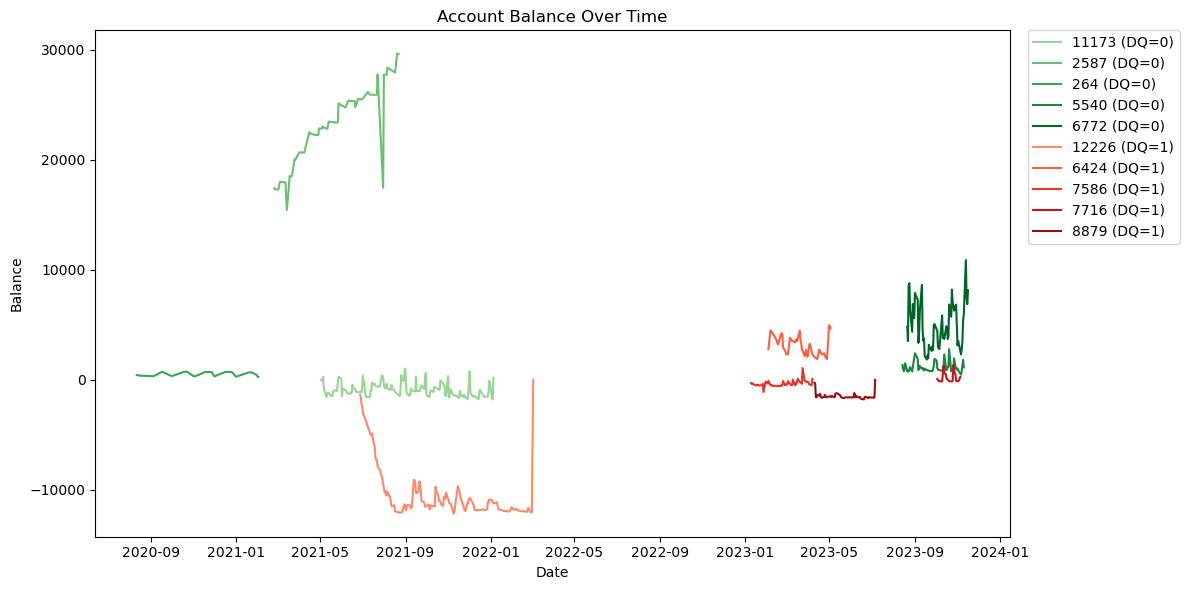

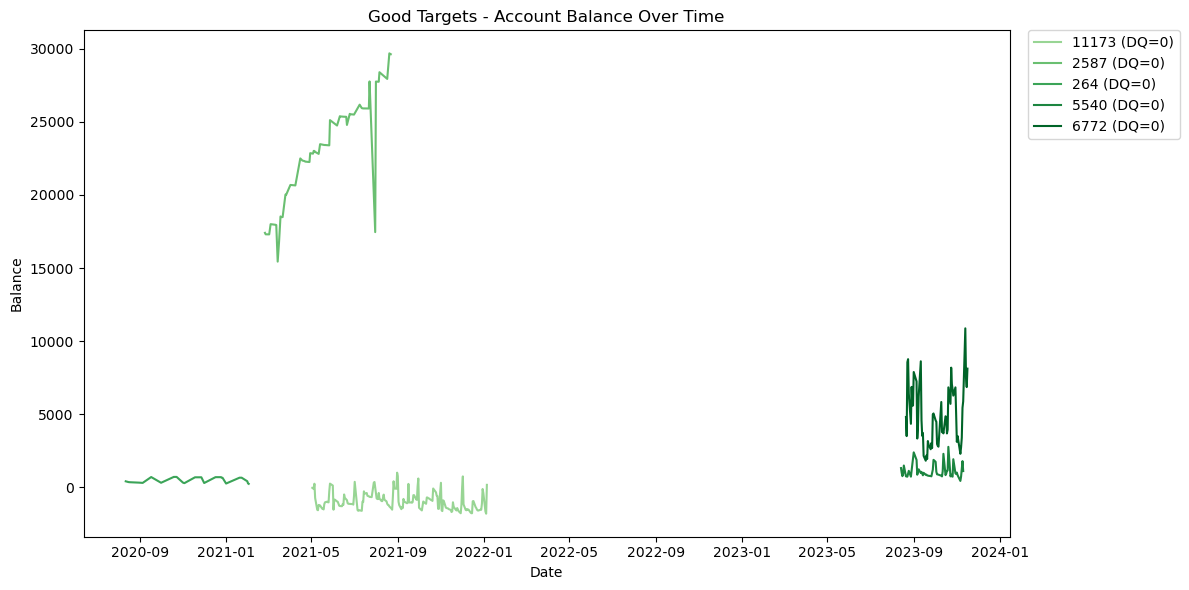

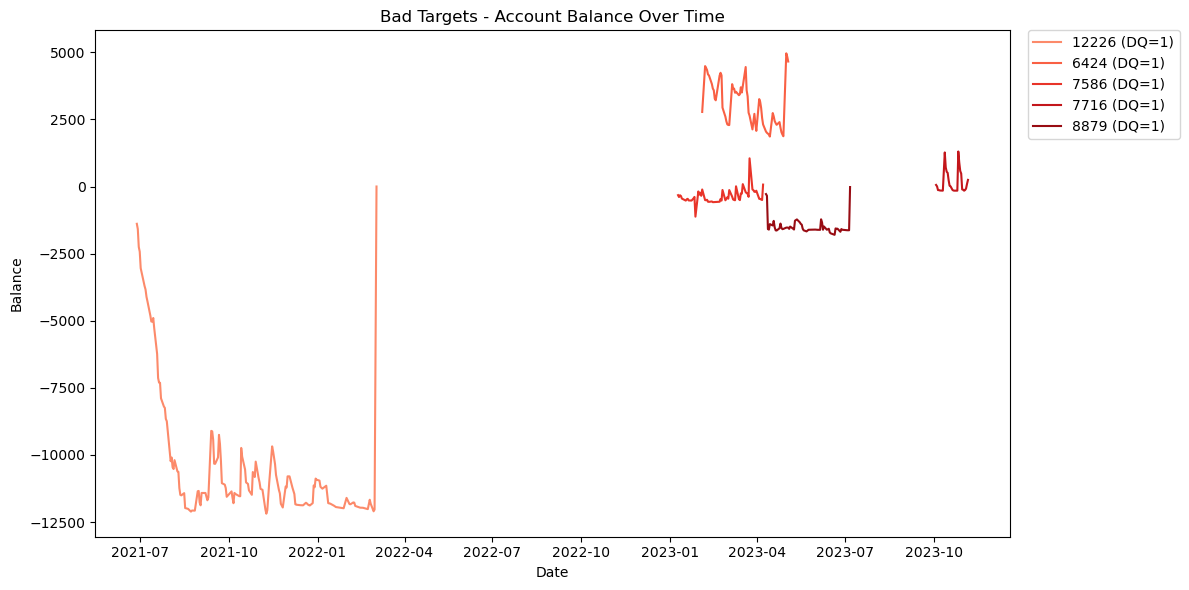

In [11]:
import matplotlib.pyplot as plt

def plot_subset(df, title):
    plt.figure(figsize=FIGSIZE)

    # split by label
    goods = df[df["DQ_TARGET"] == 0]
    bads  = df[df["DQ_TARGET"] == 1]

    # color palettes (shades)
    greens = plt.cm.Greens(np.linspace(0.4, 0.9, goods["prism_consumer_id"].nunique()))
    reds   = plt.cm.Reds(np.linspace(0.4, 0.9, bads["prism_consumer_id"].nunique()))

    # plot goods
    for (cid, g), c in zip(goods.groupby("prism_consumer_id"), greens):
        g = g.sort_values("date")
        plt.plot(g["date"], g["balance"], color=c, label=f"{cid} (DQ=0)")

    # plot bads
    for (cid, g), c in zip(bads.groupby("prism_consumer_id"), reds):
        g = g.sort_values("date")
        plt.plot(g["date"], g["balance"], color=c, label=f"{cid} (DQ=1)")

    plt.xlabel("Date")
    plt.ylabel("Balance")
    plt.title(title)
    plt.legend(**LEGEND_KWARGS)
    plt.tight_layout()
    plt.show()


# 1) 5 good + 5 bad
plot_subset(subset_mixed, "Account Balance Over Time")

# 2) good only
plot_subset(subset_good, "Good Targets - Account Balance Over Time")

# 3) bad only
plot_subset(subset_bad, "Bad Targets - Account Balance Over Time")
